# Mini Transformer from Scratch

A character-level language model built step by step using PyTorch.

## 1. Tokenization and Tensors
### Create the vocabulary

This cell finds every unique character in the text and gives each character a numeric ID.

In [1]:
text = "hello transformer"

characters = sorted(set(text))

char_to_id = {char: index for index, char in enumerate(characters)}
id_to_char = {index: char for char, index in char_to_id.items()}

print("Characters:", characters)
print("Character to ID:", char_to_id)

Characters: [' ', 'a', 'e', 'f', 'h', 'l', 'm', 'n', 'o', 'r', 's', 't']
Character to ID: {' ': 0, 'a': 1, 'e': 2, 'f': 3, 'h': 4, 'l': 5, 'm': 6, 'n': 7, 'o': 8, 'r': 9, 's': 10, 't': 11}


### Convert text to tokens and back

`encode()` converts characters into numbers. `decode()` converts those numbers back into readable text.

In [2]:
def encode(text):
    return [char_to_id[char] for char in text]

def decode(token_ids):
    return "".join(id_to_char[token_id] for token_id in token_ids)

tokens = encode(text)

print("Original:", text)
print("Tokens:", tokens)
print("Decoded:", decode(tokens))

Original: hello transformer
Tokens: [4, 2, 5, 5, 8, 0, 11, 9, 1, 7, 10, 3, 8, 9, 6, 2, 9]
Decoded: hello transformer


### Create training examples

The model receives one character and learns to predict the character that comes next.

In [4]:
import torch

data = torch.tensor(encode(text), dtype=torch.long)

inputs = data[:-1]
targets = data[1:]

print("Input: ", decode(inputs.tolist()))
print("Target:", decode(targets.tolist()))
print("Input IDs: ", inputs)
print("Target IDs:", targets)

Input:  hello transforme
Target: ello transformer
Input IDs:  tensor([ 4,  2,  5,  5,  8,  0, 11,  9,  1,  7, 10,  3,  8,  9,  6,  2])
Target IDs: tensor([ 2,  5,  5,  8,  0, 11,  9,  1,  7, 10,  3,  8,  9,  6,  2,  9])


### Understand the prediction task

This cell shows the context available to the model and the next character it must predict.

In [5]:
block_size = 4

x = data[:block_size]
y = data[1:block_size + 1]

for position in range(block_size):
    context = x[:position + 1]
    target = y[position]

    print(
        f"Input: {decode(context.tolist())!r} "
        f"→ Expected: {decode([target.item()])!r}"
    )

Input: 'h' → Expected: 'e'
Input: 'he' → Expected: 'l'
Input: 'hel' → Expected: 'l'
Input: 'hell' → Expected: 'o'


### Load the training dataset

This cell loads the Shakespeare text and displays its size and a short sample.

In [6]:
from pathlib import Path

project_root = (
    Path.cwd().parent
    if Path.cwd().name == "notebooks"
    else Path.cwd()
)

data_path = project_root / "data" / "input.txt"
text = data_path.read_text(encoding="utf-8")

print("Characters in dataset:", len(text))
print("\nSample:\n")
print(text[:300])

Characters in dataset: 1115394

Sample:

First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us


### Tokenize and split the dataset

This cell creates the full character vocabulary, converts the text into tokens, and separates training data from validation data.

In [7]:
characters = sorted(set(text))
vocab_size = len(characters)

char_to_id = {char: index for index, char in enumerate(characters)}
id_to_char = {index: char for char, index in char_to_id.items()}

def encode(text):
    return [char_to_id[char] for char in text]

def decode(token_ids):
    return "".join(id_to_char[token_id] for token_id in token_ids)

data = torch.tensor(encode(text), dtype=torch.long)

split_index = int(0.9 * len(data))
train_data = data[:split_index]
validation_data = data[split_index:]

print("Vocabulary size:", vocab_size)
print("Training tokens:", len(train_data))
print("Validation tokens:", len(validation_data))

Vocabulary size: 65
Training tokens: 1003854
Validation tokens: 111540


### Create batches of training examples

A batch contains several short text sequences. The model processes them together for faster training.

In [8]:
batch_size = 4
block_size = 8

device = "mps" if torch.backends.mps.is_available() else "cpu"

def get_batch(split):
    source = train_data if split == "train" else validation_data

    starts = torch.randint(
        0,
        len(source) - block_size,
        (batch_size,)
    )

    inputs = torch.stack([
        source[start:start + block_size]
        for start in starts
    ])

    targets = torch.stack([
        source[start + 1:start + block_size + 1]
        for start in starts
    ])

    return inputs.to(device), targets.to(device)

x_batch, y_batch = get_batch("train")

print("Input shape:", x_batch.shape)
print("Target shape:", y_batch.shape)
print("Example input: ", decode(x_batch[0].cpu().tolist()))
print("Example target:", decode(y_batch[0].cpu().tolist()))

Input shape: torch.Size([4, 8])
Target shape: torch.Size([4, 8])
Example input:  e that m
Example target:  that me


## 2. Next-Character Prediction

### Build a basic next-character predictor

This model learns which character usually follows the current character. It gives us a simple baseline to compare with the Transformer later.

In [9]:
import torch.nn as nn
import torch.nn.functional as F

class BigramLanguageModel(nn.Module):
    def __init__(self, vocab_size):
        super().__init__()

        # Each token directly stores scores for the next token.
        self.token_scores = nn.Embedding(vocab_size, vocab_size)

    def forward(self, inputs, targets=None):
        logits = self.token_scores(inputs)
        loss = None

        if targets is not None:
            batch, time, classes = logits.shape

            logits_flat = logits.reshape(batch * time, classes)
            targets_flat = targets.reshape(batch * time)

            loss = F.cross_entropy(logits_flat, targets_flat)

        return logits, loss


model = BigramLanguageModel(vocab_size).to(device)

logits, loss = model(x_batch, y_batch)

print("Logits shape:", logits.shape)
print("Initial loss:", loss.item())
print("Parameters:", sum(p.numel() for p in model.parameters()))

Logits shape: torch.Size([4, 8, 65])
Initial loss: 4.765323638916016
Parameters: 4225


### Train the baseline model

This cell repeatedly shows text examples to the model. The optimizer updates the model’s parameters to reduce prediction loss.

In [10]:
optimizer = torch.optim.AdamW(model.parameters(), lr=0.01)

training_steps = 2000
loss_history = []

for step in range(training_steps):
    x_batch, y_batch = get_batch("train")

    logits, loss = model(x_batch, y_batch)

    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()

    loss_history.append(loss.item())

    if step % 200 == 0:
        print(f"Step {step}: loss = {loss.item():.4f}")

Step 0: loss = 4.9287
Step 200: loss = 3.5157
Step 400: loss = 2.7848
Step 600: loss = 2.9801
Step 800: loss = 2.8081
Step 1000: loss = 2.7526
Step 1200: loss = 2.3249
Step 1400: loss = 2.3533
Step 1600: loss = 2.5560
Step 1800: loss = 2.4408


### Generate text with the baseline model

The model starts with one character, predicts the next character, and repeats the process to create new text.

In [11]:
@torch.no_grad()
def generate_text(model, start_token, max_new_tokens):
    model.eval()

    generated = torch.tensor(
        [[start_token]],
        dtype=torch.long,
        device=device
    )

    for _ in range(max_new_tokens):
        logits, _ = model(generated)

        next_token_logits = logits[:, -1, :]
        probabilities = F.softmax(next_token_logits, dim=-1)
        next_token = torch.multinomial(probabilities, num_samples=1)

        generated = torch.cat((generated, next_token), dim=1)

    return generated[0].cpu().tolist()


start_token = char_to_id["\n"]
generated_tokens = generate_text(model, start_token, 300)

print(decode(generated_tokens))


ANoularins JFghome, ite ofat finss pe kes he is sare, whisemy INTild y.

IS:
F;


Whain ungmbehes k cens t y alyodlirfo tricow3arselly.

Toumof alis ber:

Ho brt If gtoutes au we tar:


And gous h osthea Deenthathay!
's the yon by gs, Jodifa cthARI F.FRLUm w'ss w rved:
S:
FLe and I st borvofop t:
av


### Evaluate the baseline model

This cell measures average loss on training and validation data. Similar values suggest the model is not heavily overfitting.

In [12]:
import math

@torch.no_grad()
def estimate_loss(model, split, evaluation_batches=100):
    model.eval()
    losses = []

    for _ in range(evaluation_batches):
        x_batch, y_batch = get_batch(split)
        _, loss = model(x_batch, y_batch)
        losses.append(loss.item())

    model.train()
    return sum(losses) / len(losses)


train_loss = estimate_loss(model, "train")
validation_loss = estimate_loss(model, "validation")

print(f"Training loss:   {train_loss:.4f}")
print(f"Validation loss: {validation_loss:.4f}")
print(f"Validation perplexity: {math.exp(validation_loss):.2f}")

Training loss:   2.4891
Validation loss: 2.4883
Validation perplexity: 12.04


## 3. Embeddings and Positional Information

### Create token embeddings

Embeddings convert each token ID into a learnable vector. This gives the model a richer numeric representation than a single ID.

In [13]:
embedding_size = 32

token_embedding_table = nn.Embedding(
    vocab_size,
    embedding_size
).to(device)

x_batch, y_batch = get_batch("train")
token_embeddings = token_embedding_table(x_batch)

print("Token IDs shape:", x_batch.shape)
print("Embeddings shape:", token_embeddings.shape)

Token IDs shape: torch.Size([4, 8])
Embeddings shape: torch.Size([4, 8, 32])


### Add positional embeddings

Token embeddings describe what each character is. Positional embeddings tell the model where each character appears in the sequence.

In [14]:
position_embedding_table = nn.Embedding(
    block_size,
    embedding_size
).to(device)

positions = torch.arange(block_size, device=device)
position_embeddings = position_embedding_table(positions)

combined_embeddings = token_embeddings + position_embeddings

print("Token embeddings:", token_embeddings.shape)
print("Position embeddings:", position_embeddings.shape)
print("Combined embeddings:", combined_embeddings.shape)

Token embeddings: torch.Size([4, 8, 32])
Position embeddings: torch.Size([8, 32])
Combined embeddings: torch.Size([4, 8, 32])


## 4. Manual Self-Attention with Q, K, and V

### Create Queries, Keys, and Values

Each token creates a Query, Key, and Value. Queries search, Keys describe what is available, and Values contain the information to share.

In [16]:
head_size = 16

query_layer = nn.Linear(
    embedding_size,
    head_size,
    bias=False
).to(device)

key_layer = nn.Linear(
    embedding_size,
    head_size,
    bias=False
).to(device)

value_layer = nn.Linear(
    embedding_size,
    head_size,
    bias=False
).to(device)

queries = query_layer(combined_embeddings)
keys = key_layer(combined_embeddings)
values = value_layer(combined_embeddings)

print("Queries:", queries.shape)
print("Keys:   ", keys.shape)
print("Values: ", values.shape)

Queries: torch.Size([4, 8, 16])
Keys:    torch.Size([4, 8, 16])
Values:  torch.Size([4, 8, 16])


### Calculate attention scores

Each Query is compared with every Key using a dot product. A higher score means the two token positions are more related.

In [17]:
attention_scores = queries @ keys.transpose(-2, -1)

print("Attention scores shape:", attention_scores.shape)
print("\nScores for the first sequence:\n")
print(attention_scores[0].detach().cpu().round(decimals=2))

Attention scores shape: torch.Size([4, 8, 8])

Scores for the first sequence:

tensor([[-3.7800,  5.5100,  3.5900, -1.2300, -3.6900, -5.2600, -2.4900, -0.9600],
        [-0.1200, -0.6700, -6.0500,  1.2200, -0.8100,  4.7000,  2.0200, -1.1500],
        [ 3.1100, -0.0900, -1.6300, -1.1300, -2.7800, -1.8100,  0.6900, -0.3600],
        [-0.5400, -1.3600, -1.7100, -1.0400, -3.4400, -5.9100, -1.0900,  5.2100],
        [-2.2900, -4.2300, -3.1200,  0.0900, -0.6900, -3.5700,  1.3300,  4.3800],
        [ 3.0600, -0.3800,  1.1500,  3.6100,  2.8900, -0.9000,  2.4000,  4.7700],
        [ 3.3600,  0.9500,  5.7500,  1.8700,  0.5900, -3.1100,  2.3800,  4.8200],
        [-5.7500, -4.4700, -4.9000, -0.5200, -0.9600,  2.9900,  4.7800, -0.8800]])


## 5. Causal Masking and Attention Scaling

### Scale the attention scores

Large Query and Key vectors can produce extreme scores. Dividing by √head_size keeps the values stable before softmax.

In [18]:
scaled_scores = attention_scores / (head_size ** 0.5)

print("Before scaling:", attention_scores.std().item())
print("After scaling: ", scaled_scores.std().item())

Before scaling: 2.6726794242858887
After scaling:  0.6681698560714722


### Apply the causal mask

The causal mask hides future characters. Each position can only use itself and the characters that appeared before it.

In [19]:
sequence_length = x_batch.shape[1]

causal_mask = torch.tril(
    torch.ones(sequence_length, sequence_length, device=device)
)

masked_scores = scaled_scores.masked_fill(
    causal_mask == 0,
    float("-inf")
)

print(masked_scores[0].detach().cpu().round(decimals=2))

tensor([[-0.9400,    -inf,    -inf,    -inf,    -inf,    -inf,    -inf,    -inf],
        [-0.0300, -0.1700,    -inf,    -inf,    -inf,    -inf,    -inf,    -inf],
        [ 0.7800, -0.0200, -0.4100,    -inf,    -inf,    -inf,    -inf,    -inf],
        [-0.1400, -0.3400, -0.4300, -0.2600,    -inf,    -inf,    -inf,    -inf],
        [-0.5700, -1.0600, -0.7800,  0.0200, -0.1700,    -inf,    -inf,    -inf],
        [ 0.7600, -0.1000,  0.2900,  0.9000,  0.7200, -0.2200,    -inf,    -inf],
        [ 0.8400,  0.2400,  1.4400,  0.4700,  0.1500, -0.7800,  0.6000,    -inf],
        [-1.4400, -1.1200, -1.2200, -0.1300, -0.2400,  0.7500,  1.1900, -0.2200]])


### Convert scores into attention weights

Softmax converts the masked scores into probabilities. Each row adds up to 1 and shows how much attention is given to each allowed position.

In [20]:
attention_weights = F.softmax(masked_scores, dim=-1)

print("Attention weights:\n")
print(attention_weights[0].detach().cpu().round(decimals=2))

print("\nRow totals:")
print(attention_weights[0].sum(dim=-1).detach().cpu())

Attention weights:

tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.5300, 0.4700, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.5700, 0.2600, 0.1700, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.2900, 0.2400, 0.2200, 0.2600, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.1700, 0.1100, 0.1400, 0.3200, 0.2600, 0.0000, 0.0000, 0.0000],
        [0.2200, 0.0900, 0.1400, 0.2500, 0.2100, 0.0800, 0.0000, 0.0000],
        [0.1800, 0.1000, 0.3300, 0.1200, 0.0900, 0.0400, 0.1400, 0.0000],
        [0.0300, 0.0400, 0.0300, 0.1000, 0.0900, 0.2400, 0.3800, 0.0900]])

Row totals:
tensor([1., 1., 1., 1., 1., 1., 1., 1.])


### Combine the Value vectors

The attention weights decide how much information to collect from each Value vector. This creates a context-aware representation for every token.

In [21]:
attention_output = attention_weights @ values

print("Attention weights:", attention_weights.shape)
print("Values:           ", values.shape)
print("Attention output: ", attention_output.shape)

Attention weights: torch.Size([4, 8, 8])
Values:            torch.Size([4, 8, 16])
Attention output:  torch.Size([4, 8, 16])


### Scaled Dot-Product Attention

The complete self-attention calculation is:

$$
\text{Attention}(Q,K,V)
=
\text{softmax}
\left(
\frac{QK^T}{\sqrt{d_k}} + M
\right)V
$$

- $Q$: Queries
- $K$: Keys
- $V$: Values
- $d_k$: Size of each Key vector
- $M$: Causal mask

## 6. Multi-Head Attention

### Create a reusable attention head

This class packages the Query, Key, Value, scaling, masking, and softmax steps into one reusable attention head.

In [22]:
class AttentionHead(nn.Module):
    def __init__(self, embedding_size, head_size, block_size):
        super().__init__()

        self.query = nn.Linear(embedding_size, head_size, bias=False)
        self.key = nn.Linear(embedding_size, head_size, bias=False)
        self.value = nn.Linear(embedding_size, head_size, bias=False)

        self.register_buffer(
            "causal_mask",
            torch.tril(torch.ones(block_size, block_size))
        )

        self.scale = head_size ** -0.5

    def forward(self, x, return_weights=False):
        _, sequence_length, _ = x.shape

        queries = self.query(x)
        keys = self.key(x)
        values = self.value(x)

        scores = queries @ keys.transpose(-2, -1)
        scores = scores * self.scale

        mask = self.causal_mask[:sequence_length, :sequence_length]
        scores = scores.masked_fill(mask == 0, float("-inf"))

        weights = F.softmax(scores, dim=-1)
        output = weights @ values

        if return_weights:
            return output, weights

        return output


single_head = AttentionHead(
    embedding_size,
    head_size,
    block_size
).to(device)

single_head_output = single_head(combined_embeddings)

print("Single-head output:", single_head_output.shape)

Single-head output: torch.Size([4, 8, 16])


### Combine multiple attention heads

Each head learns different relationships between tokens. Their outputs are joined and projected back to the embedding size.

In [23]:
class MultiHeadAttention(nn.Module):
    def __init__(self, embedding_size, num_heads, block_size):
        super().__init__()

        head_size = embedding_size // num_heads

        self.heads = nn.ModuleList([
            AttentionHead(embedding_size, head_size, block_size)
            for _ in range(num_heads)
        ])

        self.output_projection = nn.Linear(
            embedding_size,
            embedding_size
        )

    def forward(self, x, return_weights=False):
        outputs = []
        all_weights = []

        for head in self.heads:
            output, weights = head(x, return_weights=True)
            outputs.append(output)
            all_weights.append(weights)

        combined = torch.cat(outputs, dim=-1)
        projected = self.output_projection(combined)

        if return_weights:
            return projected, torch.stack(all_weights, dim=1)

        return projected


num_heads = 4

multi_head_attention = MultiHeadAttention(
    embedding_size,
    num_heads,
    block_size
).to(device)

multi_head_output, all_attention_weights = multi_head_attention(
    combined_embeddings,
    return_weights=True
)

print("Multi-head output:", multi_head_output.shape)
print("Attention weights:", all_attention_weights.shape)

Multi-head output: torch.Size([4, 8, 32])
Attention weights: torch.Size([4, 4, 8, 8])


## 7. Feed-Forward Network, Residual Connections, and Normalization

### Create the feed-forward network

This network processes each token independently after attention. It expands the representation, applies a non-linear function, and reduces it back to the embedding size.

In [24]:
class FeedForward(nn.Module):
    def __init__(self, embedding_size):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(embedding_size, 4 * embedding_size),
            nn.GELU(),
            nn.Linear(4 * embedding_size, embedding_size)
        )

    def forward(self, x):
        return self.network(x)


feed_forward = FeedForward(embedding_size).to(device)
feed_forward_output = feed_forward(multi_head_output)

print("Input shape: ", multi_head_output.shape)
print("Output shape:", feed_forward_output.shape)

Input shape:  torch.Size([4, 8, 32])
Output shape: torch.Size([4, 8, 32])


### Apply normalization and a residual connection

Layer normalization keeps values stable. The residual connection adds the original input back so useful information and gradients can flow through the network.

In [25]:
layer_norm = nn.LayerNorm(embedding_size).to(device)

normalized_input = layer_norm(combined_embeddings)
attention_update = multi_head_attention(normalized_input)

residual_output = combined_embeddings + attention_update

print("Original input:   ", combined_embeddings.shape)
print("Attention update: ", attention_update.shape)
print("Residual output:  ", residual_output.shape)

Original input:    torch.Size([4, 8, 32])
Attention update:  torch.Size([4, 8, 32])
Residual output:   torch.Size([4, 8, 32])


### Build one Transformer block

A Transformer block combines multi-head attention and a feed-forward network. Normalization, residual connections, and dropout help training remain stable.

In [26]:
class TransformerBlock(nn.Module):
    def __init__(
        self,
        embedding_size,
        num_heads,
        block_size,
        dropout=0.1
    ):
        super().__init__()

        self.attention = MultiHeadAttention(
            embedding_size,
            num_heads,
            block_size
        )

        self.feed_forward = FeedForward(embedding_size)

        self.norm1 = nn.LayerNorm(embedding_size)
        self.norm2 = nn.LayerNorm(embedding_size)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        attention_update = self.attention(self.norm1(x))
        x = x + self.dropout(attention_update)

        feed_forward_update = self.feed_forward(self.norm2(x))
        x = x + self.dropout(feed_forward_update)

        return x


transformer_block = TransformerBlock(
    embedding_size,
    num_heads,
    block_size
).to(device)

block_output = transformer_block(combined_embeddings)

print("Block input: ", combined_embeddings.shape)
print("Block output:", block_output.shape)

Block input:  torch.Size([4, 8, 32])
Block output: torch.Size([4, 8, 32])


## 8. Complete Transformer and Training

### Stack the Transformer blocks

This model combines embeddings, multiple Transformer blocks, final normalization, and an output layer that predicts the next character.

In [27]:
class MiniTransformer(nn.Module):
    def __init__(
        self,
        vocab_size,
        embedding_size,
        num_heads,
        num_layers,
        block_size,
        dropout=0.1
    ):
        super().__init__()

        self.block_size = block_size

        self.token_embeddings = nn.Embedding(
            vocab_size,
            embedding_size
        )

        self.position_embeddings = nn.Embedding(
            block_size,
            embedding_size
        )

        self.blocks = nn.Sequential(*[
            TransformerBlock(
                embedding_size,
                num_heads,
                block_size,
                dropout
            )
            for _ in range(num_layers)
        ])

        self.final_norm = nn.LayerNorm(embedding_size)
        self.output_layer = nn.Linear(embedding_size, vocab_size)

    def forward(self, inputs, targets=None):
        _, sequence_length = inputs.shape

        positions = torch.arange(
            sequence_length,
            device=inputs.device
        )

        x = (
            self.token_embeddings(inputs)
            + self.position_embeddings(positions)
        )

        x = self.blocks(x)
        x = self.final_norm(x)
        logits = self.output_layer(x)

        loss = None

        if targets is not None:
            loss = F.cross_entropy(
                logits.reshape(-1, vocab_size),
                targets.reshape(-1)
            )

        return logits, loss

### Configure and create the Transformer

These settings control the model’s size, context length, and number of Transformer blocks.

In [28]:
batch_size = 32
block_size = 64
embedding_size = 128
num_heads = 4
num_layers = 4
dropout = 0.1

transformer = MiniTransformer(
    vocab_size=vocab_size,
    embedding_size=embedding_size,
    num_heads=num_heads,
    num_layers=num_layers,
    block_size=block_size,
    dropout=dropout
).to(device)

x_batch, y_batch = get_batch("train")
logits, loss = transformer(x_batch, y_batch)

parameter_count = sum(
    parameter.numel()
    for parameter in transformer.parameters()
)

print("Logits shape:", logits.shape)
print("Initial loss:", loss.item())
print(f"Parameters: {parameter_count:,}")

Logits shape: torch.Size([32, 64, 65])
Initial loss: 4.349480152130127
Parameters: 816,705


### Train the complete Transformer

This loop trains the model and periodically compares training loss with validation loss. It also records the total training time.


In [29]:
import time

optimizer = torch.optim.AdamW(
    transformer.parameters(),
    lr=3e-4
)

training_steps = 3000
evaluation_interval = 300

training_history = []
validation_history = []

start_time = time.perf_counter()

for step in range(training_steps):
    if step % evaluation_interval == 0:
        train_loss = estimate_loss(
            transformer, "train", evaluation_batches=50
        )

        validation_loss = estimate_loss(
            transformer, "validation", evaluation_batches=50
        )

        training_history.append((step, train_loss))
        validation_history.append((step, validation_loss))

        print(
            f"Step {step}: "
            f"train loss = {train_loss:.4f}, "
            f"validation loss = {validation_loss:.4f}"
        )

    x_batch, y_batch = get_batch("train")
    _, loss = transformer(x_batch, y_batch)

    optimizer.zero_grad(set_to_none=True)
    loss.backward()

    torch.nn.utils.clip_grad_norm_(
        transformer.parameters(),
        max_norm=1.0
    )

    optimizer.step()

training_minutes = (time.perf_counter() - start_time) / 60

print(f"\nTraining time: {training_minutes:.2f} minutes")

Step 0: train loss = 4.3377, validation loss = 4.3328
Step 300: train loss = 2.4129, validation loss = 2.4247
Step 600: train loss = 2.1881, validation loss = 2.2086
Step 900: train loss = 2.0483, validation loss = 2.0973
Step 1200: train loss = 1.9429, validation loss = 2.0243
Step 1500: train loss = 1.8616, validation loss = 1.9618
Step 1800: train loss = 1.7957, validation loss = 1.9201
Step 2100: train loss = 1.7411, validation loss = 1.8797
Step 2400: train loss = 1.7165, validation loss = 1.8523
Step 2700: train loss = 1.6675, validation loss = 1.8236

Training time: 0.93 minutes


## 9. Loss, Perplexity, Parameters, and Training Time

### Evaluate the trained Transformer

This cell measures the final performance and calculates perplexity. Lower loss and perplexity indicate better predictions.

In [31]:
final_train_loss = estimate_loss(
    transformer,
    "train",
    evaluation_batches=100
)

final_validation_loss = estimate_loss(
    transformer,
    "validation",
    evaluation_batches=100
)

validation_perplexity = math.exp(final_validation_loss)
generalization_gap = final_validation_loss - final_train_loss

print(f"Training loss:      {final_train_loss:.4f}")
print(f"Validation loss:    {final_validation_loss:.4f}")
print(f"Validation perplexity: {validation_perplexity:.2f}")
print(f"Generalization gap: {generalization_gap:.4f}")
print(f"Parameters:         {parameter_count:,}")
print(f"Training time:      {training_minutes:.2f} minutes")

Training loss:      1.5515
Validation loss:    1.7126
Validation perplexity: 5.54
Generalization gap: 0.1611
Parameters:         816,705
Training time:      0.93 minutes


### Visualize the loss

This graph shows how training and validation loss changed during training. It helps us identify learning progress and possible overfitting.

Matplotlib is building the font cache; this may take a moment.


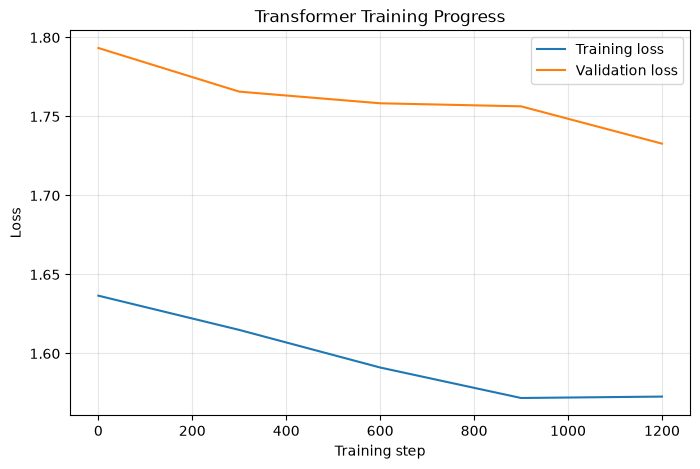

In [32]:
import matplotlib.pyplot as plt

steps = [step for step, _ in training_history]
train_losses = [loss for _, loss in training_history]
validation_losses = [loss for _, loss in validation_history]

plt.figure(figsize=(8, 5))
plt.plot(steps, train_losses, label="Training loss")
plt.plot(steps, validation_losses, label="Validation loss")

plt.xlabel("Training step")
plt.ylabel("Loss")
plt.title("Transformer Training Progress")
plt.legend()
plt.grid(alpha=0.3)

assets_path = project_root / "assets"
assets_path.mkdir(exist_ok=True)

plt.savefig(
    assets_path / "training_loss.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

### Generate text with the trained Transformer

The model repeatedly predicts a new character using up to 64 previous characters as context.

In [33]:
@torch.no_grad()
def generate_transformer_text(
    model,
    start_token,
    max_new_tokens,
    temperature=0.8
):
    model.eval()

    generated = torch.tensor(
        [[start_token]],
        dtype=torch.long,
        device=device
    )

    for _ in range(max_new_tokens):
        context = generated[:, -model.block_size:]

        logits, _ = model(context)
        next_logits = logits[:, -1, :] / temperature

        probabilities = F.softmax(next_logits, dim=-1)
        next_token = torch.multinomial(
            probabilities,
            num_samples=1
        )

        generated = torch.cat(
            (generated, next_token),
            dim=1
        )

    return generated[0].cpu().tolist()


generated_tokens = generate_transformer_text(
    transformer,
    start_token=char_to_id["\n"],
    max_new_tokens=500
)

print(decode(generated_tokens))


I will paress of contion in your bless Whered deed,
And have of her words worse the chear with her lead
Than shall farewell the never conful the cannot of unforcuse
Ere you marrerable his frant; how to dour to up;
I am that for all again woen he to the was that the hath manner's to
Will and again a my lording alant is begin
Is our trumptien of let's battlen in his couried,
Mark a patient the scape of time a man;
And very this blood fair in looks of a marrient,
To posteword him, to you thou to my


## 10. Attention Visualization

### Visualize one attention head

This heatmap shows which earlier characters one attention head focuses on while processing each character.

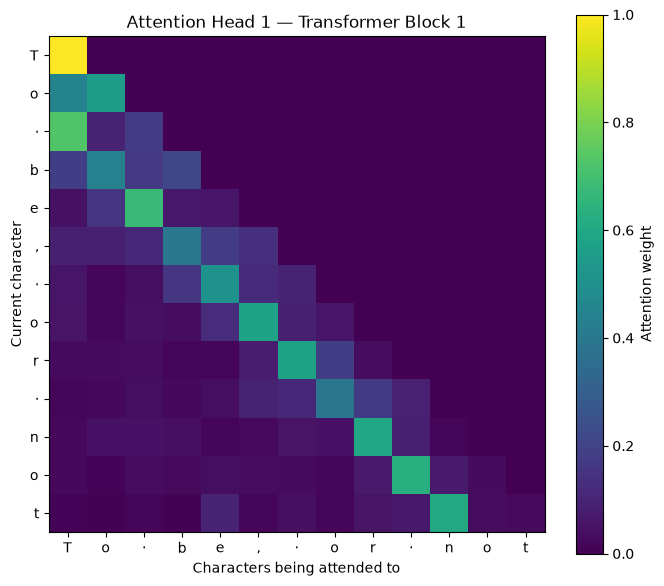

In [35]:
sample_text = "To be, or not"
sample_tokens = torch.tensor(
    [encode(sample_text)],
    dtype=torch.long,
    device=device
)

transformer.eval()

with torch.no_grad():
    sequence_length = sample_tokens.shape[1]
    positions = torch.arange(sequence_length, device=device)

    x = (
        transformer.token_embeddings(sample_tokens)
        + transformer.position_embeddings(positions)
    )

    first_block = transformer.blocks[0]
    normalized_x = first_block.norm1(x)

    _, attention_weights = first_block.attention(
        normalized_x,
        return_weights=True
    )

head_to_display = 0
weights = attention_weights[
    0, head_to_display
].cpu().numpy()

labels = [
    "·" if character == " " else character
    for character in sample_text
]

plt.figure(figsize=(8, 7))
plt.imshow(weights, cmap="viridis")

plt.xticks(range(len(labels)), labels)
plt.yticks(range(len(labels)), labels)
plt.xlabel("Characters being attended to")
plt.ylabel("Current character")
plt.title("Attention Head 1 — Transformer Block 1")
plt.colorbar(label="Attention weight")

plt.savefig(
    assets_path / "attention_head.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

## 11. LSTM Comparison

### Build an LSTM baseline

The LSTM processes characters sequentially and remembers earlier information. We will train it on the same data and compare it with the Transformer.

In [ ]:
class LSTMLanguageModel(nn.Module):
    def __init__(
        self,
        vocab_size,
        embedding_size,
        hidden_size,
        num_layers,
        block_size,
        dropout=0.1
    ):
        super().__init__()

        self.block_size = block_size

        self.token_embeddings = nn.Embedding(
            vocab_size,
            embedding_size
        )

        self.lstm = nn.LSTM(
            input_size=embedding_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout
        )

        self.output_layer = nn.Linear(
            hidden_size,
            vocab_size
        )

    def forward(self, inputs, targets=None):
        x = self.token_embeddings(inputs)
        x, _ = self.lstm(x)
        logits = self.output_layer(x)

        loss = None

        if targets is not None:
            loss = F.cross_entropy(
                logits.reshape(-1, logits.shape[-1]),
                targets.reshape(-1)
            )

        return logits, loss


lstm_model = LSTMLanguageModel(
    vocab_size=vocab_size,
    embedding_size=embedding_size,
    hidden_size=224,
    num_layers=2,
    block_size=block_size,
    dropout=dropout
).to(device)

lstm_parameters = sum(
    parameter.numel()
    for parameter in lstm_model.parameters()
)

print(f"LSTM parameters:        {lstm_parameters:,}")
print(f"Transformer parameters: {parameter_count:,}")

LSTM parameters:        743,329
Transformer parameters: 816,705


### Train the LSTM baseline

The LSTM uses the same dataset, batch size, context length, learning rate, and training steps as the Transformer.

In [37]:
lstm_optimizer = torch.optim.AdamW(
    lstm_model.parameters(),
    lr=3e-4
)

lstm_training_history = []
lstm_validation_history = []

start_time = time.perf_counter()

for step in range(training_steps):
    if step % evaluation_interval == 0:
        train_loss = estimate_loss(
            lstm_model, "train", evaluation_batches=50
        )

        validation_loss = estimate_loss(
            lstm_model, "validation", evaluation_batches=50
        )

        lstm_training_history.append((step, train_loss))
        lstm_validation_history.append((step, validation_loss))

        print(
            f"Step {step}: "
            f"train loss = {train_loss:.4f}, "
            f"validation loss = {validation_loss:.4f}"
        )

    x_batch, y_batch = get_batch("train")
    _, loss = lstm_model(x_batch, y_batch)

    lstm_optimizer.zero_grad(set_to_none=True)
    loss.backward()

    torch.nn.utils.clip_grad_norm_(
        lstm_model.parameters(),
        max_norm=1.0
    )

    lstm_optimizer.step()

lstm_training_minutes = (
    time.perf_counter() - start_time
) / 60

print(
    f"\nLSTM training time: "
    f"{lstm_training_minutes:.2f} minutes"
)

Step 0: train loss = 4.1649, validation loss = 4.1652
Step 300: train loss = 2.3183, validation loss = 2.3021
Step 600: train loss = 2.0485, validation loss = 2.0874
Step 900: train loss = 1.9100, validation loss = 1.9819
Step 1200: train loss = 1.7991, validation loss = 1.9100
Step 1500: train loss = 1.7466, validation loss = 1.8796
Step 1800: train loss = 1.6874, validation loss = 1.8289
Step 2100: train loss = 1.6495, validation loss = 1.8103
Step 2400: train loss = 1.6228, validation loss = 1.7666
Step 2700: train loss = 1.5912, validation loss = 1.7507

LSTM training time: 0.68 minutes


### Compare the LSTM and Transformer

This table compares model size, validation loss, perplexity, and training time under similar training conditions.

In [38]:
from IPython.display import display, Markdown

lstm_train_loss = estimate_loss(
    lstm_model,
    "train",
    evaluation_batches=100
)

lstm_validation_loss = estimate_loss(
    lstm_model,
    "validation",
    evaluation_batches=100
)

lstm_perplexity = math.exp(lstm_validation_loss)

comparison_table = f"""
| Model | Parameters | Train Loss | Validation Loss | Perplexity | Time |
|---|---:|---:|---:|---:|---:|
| Transformer | {parameter_count:,} | {final_train_loss:.3f} | {final_validation_loss:.3f} | {validation_perplexity:.2f} | {training_minutes:.2f} min |
| LSTM | {lstm_parameters:,} | {lstm_train_loss:.3f} | {lstm_validation_loss:.3f} | {lstm_perplexity:.2f} | {lstm_training_minutes:.2f} min |
"""

display(Markdown(comparison_table))


| Model | Parameters | Train Loss | Validation Loss | Perplexity | Time |
|---|---:|---:|---:|---:|---:|
| Transformer | 816,705 | 1.552 | 1.713 | 5.54 | 0.93 min |
| LSTM | 743,329 | 1.574 | 1.724 | 5.61 | 0.68 min |


## 12. Unit Tests

### Test model shapes and causal masking

These checks confirm that the model returns the expected shape and that attention never uses future tokens.

In [39]:
transformer.eval()

test_inputs = torch.randint(
    0,
    vocab_size,
    (2, block_size),
    device=device
)

with torch.no_grad():
    test_logits, _ = transformer(test_inputs)

assert test_logits.shape == (
    2,
    block_size,
    vocab_size
)

test_head = AttentionHead(
    embedding_size,
    embedding_size // num_heads,
    block_size
).to(device)

test_embeddings = torch.randn(
    2,
    block_size,
    embedding_size,
    device=device
)

with torch.no_grad():
    _, test_weights = test_head(
        test_embeddings,
        return_weights=True
    )

future_positions = torch.triu(
    torch.ones(
        block_size,
        block_size,
        dtype=torch.bool,
        device=device
    ),
    diagonal=1
)

future_weights = test_weights[:, future_positions]

assert torch.allclose(
    future_weights,
    torch.zeros_like(future_weights)
)

print("✓ Output shape test passed")
print("✓ Causal mask test passed")

✓ Output shape test passed
✓ Causal mask test passed


## 13. Interactive Demo

### Save the trained model

This cell saves the learned parameters, model settings, and character vocabulary so the model can be loaded without training again.

In [40]:
checkpoint_path = project_root / "checkpoints"
checkpoint_path.mkdir(exist_ok=True)

torch.save(
    {
        "model_state_dict": transformer.state_dict(),
        "config": {
            "vocab_size": vocab_size,
            "embedding_size": embedding_size,
            "num_heads": num_heads,
            "num_layers": num_layers,
            "block_size": block_size,
            "dropout": dropout
        },
        "char_to_id": char_to_id,
        "id_to_char": id_to_char
    },
    checkpoint_path / "mini_transformer.pt"
)

print("Model saved to checkpoints/mini_transformer.pt")

Model saved to checkpoints/mini_transformer.pt
